In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
diamonds = sns.load_dataset('diamonds')
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
diamonds.head()
diamonds.info()
diamonds.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [4]:
diamonds[(diamonds['x'] == 0) | (diamonds['y'] == 0) | (diamonds['z'] == 0)]

,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24394,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


In [5]:
print(f"Öncesi: {len(diamonds)}")

diamonds_clean = diamonds[(diamonds['x'] > 0) & (diamonds['y'] > 0) & (diamonds['z'] > 0)]

print(f"Sonrası: {len(diamonds_clean)}")

Öncesi: 53940
Sonrası: 53920


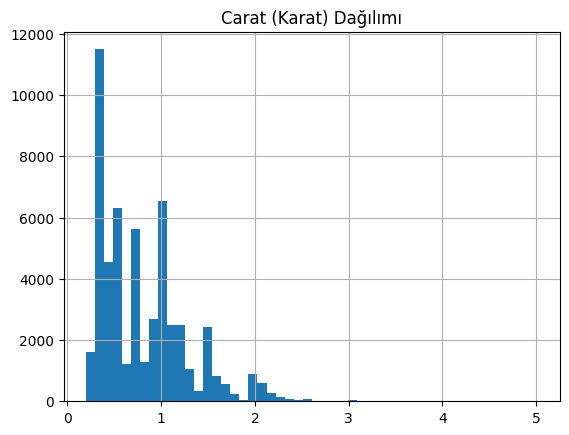

In [6]:
diamonds_clean['carat'].hist(bins=50)
plt.title('Carat (Karat) Dağılımı')
plt.show()

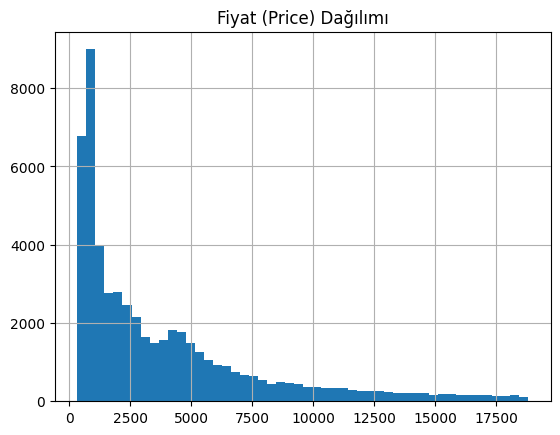

In [7]:
diamonds_clean['price'].hist(bins=50)
plt.title('Fiyat (Price) Dağılımı')
plt.show()

In [8]:
price_limit = diamonds_clean['price'].quantile(0.99)
print(f"Fiyatın %99'luk sınırı: {price_limit}")

print(f"Öncesi: {len(diamonds_clean)}")
diamonds_clean = diamonds_clean[diamonds_clean['price'] < price_limit]
print(f"Sonrası: {len(diamonds_clean)}")

Fiyatın %99'luk sınırı: 17365.809999999998
Öncesi: 53920
Sonrası: 53380


In [10]:
carat_limit = diamonds_clean['carat'].quantile(0.99)
print(f"Karatın %99'luk sınırı: {carat_limit}")
print(f"Öncesi: {len(diamonds_clean)}")
diamonds_clean = diamonds_clean[diamonds_clean['carat'] < carat_limit]
print(f"Sonrası: {len(diamonds_clean)}")

Karatın %99'luk sınırı: 2.12
Öncesi: 53380
Sonrası: 52844


Şimdi Adım 3'e geçiyoruz: Kategorik Değişkenleri Encoding

Hatırlarsan cut, color, clarity sütunları hâlâ kategori (category) tipinde duruyor. Bunları sayıya çevirmemiz lazım, ama bu sefer Titanic'ten farklı bir yöntem kullanacağız çünkü önemli bir fark var — bunu birlikte keşfedelim:

In [11]:
print(diamonds_clean['cut'].unique())
print(diamonds_clean['color'].unique())
print(diamonds_clean['clarity'].unique())


['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']


In [12]:
cut_order = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
color_order = {'J': 0, 'I': 1, 'H': 2, 'G': 3, 'F': 4, 'E': 5, 'D': 6}
clarity_order = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4, 'VVS2': 5, 'VVS1': 6, 'IF': 7}

diamonds_clean['cut_encoded'] = diamonds_clean['cut'].map(cut_order)
diamonds_clean['color_encoded'] = diamonds_clean['color'].map(color_order)
diamonds_clean['clarity_encoded'] = diamonds_clean['clarity'].map(clarity_order)

diamonds_clean[['cut', 'cut_encoded', 'color', 'color_encoded', 'clarity', 'clarity_encoded']].head()


,cut,cut_encoded,color,color_encoded,clarity,clarity_encoded
0,Ideal,4,E,5,SI2,1
1,Premium,3,E,5,SI1,2
2,Good,1,E,5,VS1,4
3,Premium,3,I,1,VS2,3
4,Good,1,J,0,SI2,1


Şimdi Adım 4: Korelasyon Analizi

Artık tüm sütunlar sayısal, korelasyona bakabiliriz. Hangi özelliğin fiyatla en güçlü ilişkide olduğunu görelim — bu sefer sen tahmin et: carat mı, yoksa encoding yaptığımız cut/color/clarity'den biri mi daha güçlü çıkar sence?

In [13]:
correlation = diamonds_clean.corr(numeric_only=True)['price'].sort_values(ascending=False)
print(correlation)

price    1.000000
carat    0.918582
x        0.883283
z        0.862880
y        0.861736
table    0.125889
depth   -0.007878
Name: price, dtype: float64


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = diamonds_clean.drop(columns=['price', 'cut', 'color', 'clarity'])
y = diamonds_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_diamond = LinearRegression()
model_diamond.fit(X_train, y_train)

print("Model eğitildi!")

Model eğitildi!


In [16]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

y_pred = model_diamond.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print(f"Model MAE: {mae:.2f}$")
print(f"Model R²: {r2:.3f}")
print(f"Baseline MAE: {baseline_mae:.2f}$")


Model MAE: 717.65$
Model R²: 0.908
Baseline MAE: 2744.54$
